<a href="https://www.kaggle.com/code/mrafraim/dl-day-59-fine-tuning-a-pretrained-yolo-model?scriptVersionId=341447473" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

# Day 59: Fine-Tuning a Pretrained YOLO Model

Welcome to Day 59!


You'll Learn Today:

1. Why fine-tuning is preferred over training from scratch
2. Transfer learning in object detection
3. YOLO dataset structure and configuration
4. Loading pretrained YOLO weights
5. Training on a custom dataset
6. Learning rate and batch size tuning
7. Evaluating fine-tuned models
8. Common mistakes and debugging strategies

By the end of today, you should be able to:

✔ Prepare a YOLO dataset

✔ Load pretrained YOLO weights

✔ Fine-tune on a custom dataset

✔ Evaluate model performance

✔ Explain why transfer learning works


If you found this notebook helpful, your <b style="color:skyblue;">UPVOTE</b> would be greatly appreciated! It helps others discover the work and supports continuous improvement.

---

# Why Fine-Tuning Exists

Training an object detector from scratch is expensive.

The model must learn:

- Edges
- Corners
- Textures
- Shapes
- Object parts
- Full objects

This requires:

- Large datasets
- Long training times
- Significant compute resources

Instead, we start from a pretrained model.

A pretrained YOLO model already understands general visual patterns.

Fine-tuning means:

Keep most of that visual knowledge

↓

Adapt it to your specific dataset

This approach is called:

**Transfer Learning**

# Training From Scratch vs Fine-Tuning

| Aspect | Training From Scratch | Fine-Tuning |
|----------|----------|----------|
| Data Requirement | Very High | Low–Medium |
| Training Time | Long | Short |
| Compute Cost | High | Lower |
| Risk of Failure | High | Low |
| Recommended for Beginners | No | Yes |

In practice:

> Most real-world projects begin with pretrained weights.

**Example**

Suppose YOLO was originally trained on COCO.

COCO contains classes such as:

- Person
- Car
- Bicycle
- Dog
- Cat

Your task:

Detect Hard Hat of Workers.

Instead of learning vision from zero,

YOLO reuses existing visual features and learns:

"These shapes correspond to my new classes."

This dramatically reduces training time.

# Today's Goal

We will take:

Pretrained YOLOv8

and adapt it to:

> Hard Hat Detection Dataset

Classes:

1. Helmet
2. Head
3. Person

This is how object detection is commonly done in industry.

# Dataset Overview

Dataset:

> Hard Hat Detection

Kaggle Link:

https://www.kaggle.com/datasets/andrewmvd/hard-hat-detection

Dataset contains:

✔ ~5000 images

✔ Construction workers

✔ Helmets

✔ Heads

✔ Persons

Annotation Format:

>Pascal VOC XML
>
>NOT YOLO format

## Important Reality Check

The dataset is NOT ready for YOLO training.

Current format:

> images/
> annotations/

Each annotation is stored as:

> image_001.xml

YOLO expects:

> image_001.txt

Therefore:

VOC XML

↓
      
YOLO TXT


conversion is required.

---

<p style="text-align:center; color:green; font-size:18px;">(Optional)</p> 

### Understanding Pascal VOC Annotations

Example XML:

```xml

<annotation>
    <filename>image001.jpg</filename>
    <size>
        <width>640</width>
        <height>480</height>
        <depth>3</depth>
    </size>
    <object>
        <name>dog</name>
        <bndbox>
            <xmin>48</xmin>
            <ymin>240</ymin>
            <xmax>300</xmax>
            <ymax>400</ymax>
        </bndbox>
    </object>
</annotation>

```

This stores:

- Whole Image size
- Class name
- Bounding box coordinates

### Understanding YOLO Annotations

YOLO format:

`class_id x_center y_center width height`

Example:

`0 0.45 0.38 0.20 0.30`

Important:

Coordinates are normalized between 0 and 1.

Example with different object sizes and classes on a standard HD image (1920 pixels wide by 1080 pixels tall):

`0 0.15 0.30 0.10 0.20`

`1 0.75 0.65 0.30 0.40`

**Breakdown of Line 1 (Class 0: Person)**

* 0: Object Class (e.g., Person).
* 0.15: Center is 15% from the left edge.
* 0.30: Center is 30% from the top edge.
* 0.10: Box takes up 10% of the image width.
* 0.20: Box takes up 20% of the image height. [1, 2, 3, 4] 

**Breakdown of Line 2 (Class 1: Car)**

* 1: Object Class (e.g., Car).
* 0.75: Center is 75% from the left edge (on the right side).
* 0.65: Center is 65% from the top edge (near the bottom).
* 0.30: Box takes up 30% of the image width (a larger object).
* 0.40: Box takes up 40% of the image height. [5, 6] 

---

## Expected YOLO Dataset Structure

dataset/

├── images/

│   ├── train/

│   └── val/

│

├── labels/

│   ├── train/

│   └── val/

│

└── data.yaml

YOLO automatically matches:

> image.jpg
> 
> image.txt

## Understanding YOLO Labels

Each annotation file contains:

`class_id x_center y_center width height`

Example:

0 0.51 0.42 0.15 0.20

Meaning:

Class = 0

Bounding box center = (0.51, 0.42)

Width = 15% of image

Height = 20% of image

Coordinates are normalized between 0 and 1.

## `data.yaml` Configuration File

A `data.yaml` file is just a text file used to give instructions to a computer program (usually an AI or machine learning model).

It acts like a map that tells the computer two main things:

- **Where to find pictures:** The folder paths for your training and testing images.
- **What to look for:** A list of the objects you want the computer to recognize.

If you open a data.yaml file in a text editor, it looks like this:

```yaml

# 1. Where the pictures are stored
train: ./dataset/train_images
val: ./dataset/validation_images

# 2. How many things you want to find
nc: 3                                  # nc stands for Number of Classes.

# 3. The names of those things
names: ['cat', 'dog', 'bird']

```

# Step 1 - Install YOLO

If using Kaggle or Colab:

In [1]:
!pip install ultralytics -q

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 45.5/45.5 kB 1.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 24.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.2/12.2 MB 101.9 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
dask-cuda 26.2.0 requires cuda-core==0.3.*, but you have cuda-core 1.0.1 which is incompatible.
dask-cuda 26.2.0 requires numba-cuda<0.23.0,>=0.22.1, but you have numba-cuda 0.30.2 which is incompatible.
distributed-ucxx-cu12 0.48.0 requires numba-cuda[cu12]<0.23.0,>=0.22.1, but you have numba-cuda 0.30.2 which is incompatible.
cuml-cu12 26.2.0 requires numba<0.62.0,>=0.60.0, but you have numba 0.65.1 which is incompatible.
cuml-cu12 26.2.0 requires numba-cuda[cu12]<0.23.0,>=0.22.1, but you have numba-cuda 0.30.2 which is incompatible.
ucxx-cu12 0.48.0 requires numba-cuda[cu12]<0.2

# Step 2 - Import Libraries

The ultralytics package provides pretrained models and training utilities.

In [2]:
# Imports the YOLO class from the Ultralytics library to load, train, and run YOLO models
from ultralytics import YOLO

# Imports the built-in operating system module to interact with files, folders, and paths
import os

# Imports the shell utilities module used for high-level file operations like copying or moving files
import shutil


Creating new Ultralytics Settings v0.0.7 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.


# Step 3 - Prepare Dataset

Download:

> Hard Hat Detection

from Kaggle.

Upload dataset to notebook.

After extraction:

dataset/

├── annotations/

├── images/

Verify files before proceeding.

# Step 4 - Convert VOC XML to YOLO

Because dataset annotations are XML,
we must convert them to YOLO format.

You may:

Option A:
Use a conversion script

Option B:
Use Roboflow conversion tools

Goal:

`annotations.xml`

↓

`labels.txt`

## 4.1 Understand Dataset Structure

In [3]:
DATASET_PATH = "/kaggle/input/datasets/mrafraim/hard-hat-dataset/hard_hat_dataset"

print(os.listdir(DATASET_PATH))

['annotations', 'images']


## 4.2 Define Class Mapping

In [4]:
class_map = {
    "helmet": 0,
    "head": 1,
    "person": 2
}

## 4.3 Conversion Logic

YOLO format requires normalization:

- `x_center = (xmin + xmax) / 2 / image_width`
- `y_center = (ymin + ymax) / 2 / image_height`
- `width    = (xmax - xmin) / image_width`
- `height   = (ymax - ymin) / image_height`

## 4.4 Full Conversion Script

In [5]:
# Create output folder

output_label_dir = "/kaggle/working/labels"
os.makedirs(output_label_dir, exist_ok=True)

In [6]:
# XML → YOLO Converter

import xml.etree.ElementTree as ET

def convert_voc_to_yolo(xml_file, output_file, class_map):

    tree = ET.parse(xml_file)
    root = tree.getroot()

    size = root.find("size")
    img_w = int(size.find("width").text)
    img_h = int(size.find("height").text)

    yolo_lines = []

    for obj in root.findall("object"):
        class_name = obj.find("name").text

        if class_name not in class_map:
            continue

        class_id = class_map[class_name]

        bndbox = obj.find("bndbox")
        xmin = float(bndbox.find("xmin").text)
        ymin = float(bndbox.find("ymin").text)
        xmax = float(bndbox.find("xmax").text)
        ymax = float(bndbox.find("ymax").text)

        # YOLO conversion
        x_center = (xmin + xmax) / 2.0 / img_w
        y_center = (ymin + ymax) / 2.0 / img_h
        width = (xmax - xmin) / img_w
        height = (ymax - ymin) / img_h

        yolo_lines.append(
            f"{class_id} {x_center} {y_center} {width} {height}"
        )

    with open(output_file, "w") as f:
        f.write("\n".join(yolo_lines))

In [7]:
# Batch Convert All XML Files

xml_dir = "/kaggle/input/datasets/mrafraim/hard-hat-dataset/hard_hat_dataset/annotations"

for xml_file in os.listdir(xml_dir):

    if not xml_file.endswith(".xml"):
        continue

    full_xml_path = os.path.join(xml_dir, xml_file)

    output_txt_path = os.path.join(
        output_label_dir,
        xml_file.replace(".xml", ".txt")
    )

    convert_voc_to_yolo(full_xml_path, output_txt_path, class_map)

In [8]:
print(os.listdir(output_label_dir)[:5])

['hard_hat_workers1363.txt', 'hard_hat_workers669.txt', 'hard_hat_workers4833.txt', 'hard_hat_workers1346.txt', 'hard_hat_workers649.txt']


# Step 5 - Train / Validation Split

## 5.1 Define Paths

In [9]:
import random

images_path = "/kaggle/input/datasets/mrafraim/hard-hat-dataset/hard_hat_dataset/images"
labels_path = "/kaggle/working/labels"

output_base = "/kaggle/working/dataset"

train_img_dir = os.path.join(output_base, "images/train")
val_img_dir   = os.path.join(output_base, "images/val")

train_lbl_dir = os.path.join(output_base, "labels/train")
val_lbl_dir   = os.path.join(output_base, "labels/val")

# create folders
for path in [train_img_dir, val_img_dir, train_lbl_dir, val_lbl_dir]:
    os.makedirs(path, exist_ok=True)

## 5.2 Get All Images

In [10]:
image_files = [f for f in os.listdir(images_path) if f.endswith(".png")]

print("Total images:", len(image_files))

Total images: 5000


## 5.3 Shuffle Dataset

Prevents biased splits (e.g., similar images grouped together)

In [11]:
random.seed(42)
random.shuffle(image_files)

## 5.4 Train / Val Split (80/20)

In [12]:
split_ratio = 0.8

train_size = int(len(image_files) * split_ratio)

train_files = image_files[:train_size]
val_files   = image_files[train_size:]

print("Train:", len(train_files))
print("Val:", len(val_files))

Train: 4000
Val: 1000


## 5.5 Copy Files Properly

We move BOTH:

- image
- corresponding label

In [13]:
# train set

for img in train_files:

    img_path = os.path.join(images_path, img)
    lbl_path = os.path.join(labels_path, img.replace(".png", ".txt"))

    shutil.copy(img_path, train_img_dir)
    
    if os.path.exists(lbl_path):
        shutil.copy(lbl_path, train_lbl_dir)

In [14]:
# validation set 

for img in val_files:

    img_path = os.path.join(images_path, img)
    lbl_path = os.path.join(labels_path, img.replace(".png", ".txt"))

    shutil.copy(img_path, val_img_dir)
    
    if os.path.exists(lbl_path):
        shutil.copy(lbl_path, val_lbl_dir)

## 5.6 Sanity Check

In [15]:
print("Train images:", len(os.listdir(train_img_dir)))
print("Val images:", len(os.listdir(val_img_dir)))

Train images: 4000
Val images: 1000


In [16]:
print("Train labels:", len(os.listdir(train_lbl_dir)))
print("Val labels:", len(os.listdir(val_lbl_dir)))

Train labels: 4000
Val labels: 1000


# Step 6 - Create `data.yaml`

### What is `data.yaml`?

YOLO does NOT automatically understand our dataset.

We must explicitly define:

* where images are
* where labels are
* what classes exist

Think of it as:

> `YOLO` = engine
> 
> `data.yaml` = GPS + instructions


## 6.1 Create `data.yaml`

We save it inside `/kaggle/working/`

In [17]:
import yaml

dataset_path = "/kaggle/working/dataset"

data_yaml = {
    "path": dataset_path,

    "train": "images/train",
    "val": "images/val",

    "names": {
        0: "helmet",
        1: "head",
        2: "person"
    }
}

yaml_path = "/kaggle/working/data.yaml"

with open(yaml_path, "w") as f:
    yaml.dump(data_yaml, f, sort_keys=False)

print("data.yaml created at:", yaml_path)


data.yaml created at: /kaggle/working/data.yaml


## 6.2 Sanity Check  

Run this before training:

In [18]:
with open(yaml_path, "r") as f:
    config = yaml.safe_load(f)

print(config)

{'path': '/kaggle/working/dataset', 'train': 'images/train', 'val': 'images/val', 'names': {0: 'helmet', 1: 'head', 2: 'person'}}


Check:

✔ path correct

✔ train/val exist

✔ names correct

# Step 7 - Install & Verify YOLOv8 Environment

Before training, we need to ensure that:

- Ultralytics (YOLOv8) is installed
- PyTorch is available
- A GPU is detected
- Dataset configuration (`data.yaml`) is accessible

This step prevents runtime errors during training.


### Why This Step Matters

Training can take several minutes or hours.

It is better to verify that the environment is configured correctly before launching training.

We will check:

- YOLO installation
- PyTorch version
- CUDA availability
- Dataset configuration

In [19]:
# Import Libraries

from ultralytics import YOLO
import torch

In [20]:
# Verify Installation

import ultralytics

print("Ultralytics Version:", ultralytics.__version__)

Ultralytics Version: 8.4.117


In [21]:
# Verify PyTorch

print("PyTorch Version:", torch.__version__)

PyTorch Version: 2.10.0+cu128


In [22]:
# Check GPU Availability

print("CUDA Available:", torch.cuda.is_available())

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

CUDA Available: True
GPU: Tesla T4


In [23]:
# Verify Dataset Configuration


yaml_path = "/kaggle/working/data.yaml"

print("Exists:", os.path.exists(yaml_path))

Exists: True


In [24]:
# Display `data.yaml`

with open(yaml_path) as f:
    print(f.read())

path: /kaggle/working/dataset
train: images/train
val: images/val
names:
  0: helmet
  1: head
  2: person



In [25]:
# Load a Pretrained YOLOv8 Model

model = YOLO("yolov8n.pt")

### Why Use `yolov8n.pt`?

YOLOv8 comes in multiple sizes:

| Model | Speed | Accuracy | GPU Requirement |
|--------|--------|----------|-----------------|
| YOLOv8n | Fastest | Good | Low |
| YOLOv8s | Fast | Better | Medium |
| YOLOv8m | Medium | High | Higher |
| YOLOv8l | Slow | Very High | High |
| YOLOv8x | Slowest | Best | Very High |

For learning and Kaggle GPUs, **YOLOv8n** is the best starting point because it trains quickly while demonstrating the full workflow.


# Step 8 - Train (Fine-Tune) YOLOv8


We already have:

- ✅ Dataset
- ✅ YOLO labels
- ✅ Train/Validation split
- ✅ `data.yaml`
- ✅ Ultralytics installed
- ✅ GPU ready

Now we'll **fine-tune a pretrained YOLOv8 model** on our `Hard Hat Detection dataset`.

Rather than training from scratch, we start from a model that has already learned general visual features from the COCO dataset.

This is called **Transfer Learning**.

### Why Transfer Learning?

Training an object detector from scratch requires:

- Hundreds of thousands of images
- Several days of GPU time
- Careful hyperparameter tuning

Instead, we use a pretrained model.

The pretrained model already understands:

- edges
- textures
- shapes
- object parts

Fine-tuning teaches it one new concept:

> "Detect hard hats."

This approach:

- trains faster
- needs less data
- usually achieves better accuracy

In [26]:
# Start Training

results = model.train(

    # Dataset configuration
    data= yaml_path,

    # Number of training epochs
    epochs=30,

    # Input image size
    imgsz=640,

    # Batch size
    batch=16,

    # Optimizer learning rate
    lr0=0.001,

    # Save checkpoints
    save=True,

    # Save training plots
    plots=True,

    # Project folder
    project="HardHat_Project",

    # Experiment name
    name="YOLOv8_Finetuning"
)

Ultralytics 8.4.117 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14912MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, channels_last=False, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, cls_remap=True, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/kaggle/working/data.yaml, degrees=0.0, deterministic=True, device=, dfl=1.5, dgrad=0.5, dis=6.0, distill_model=None, dlam=1.0, dlog=1.0, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=30, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.001, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=YOLOv8_Finetuning, nbs=64, nms=Fals

In [27]:
run_dir = "/kaggle/working/runs/detect/HardHat_Project/YOLOv8_Finetuning"

for file in sorted(os.listdir(run_dir)):
    print(file)

BoxF1_curve.png
BoxPR_curve.png
BoxP_curve.png
BoxR_curve.png
args.yaml
confusion_matrix.png
confusion_matrix_normalized.png
labels.jpg
results.csv
results.png
train_batch0.jpg
train_batch1.jpg
train_batch2.jpg
train_batch5000.jpg
train_batch5001.jpg
train_batch5002.jpg
val_batch0_labels.jpg
val_batch0_pred.jpg
val_batch1_labels.jpg
val_batch1_pred.jpg
val_batch2_labels.jpg
val_batch2_pred.jpg
weights


# Step 8 - Post-Training Analysis

Training is finished. Now we answer:

> **"How well did the model learn, where does it fail, and why?"**

## 8.1 Analyze the Training Curves (`results.png`)

### Goal

Determine whether the model:

* Learned successfully
* Underfit
* Overfit
* Converged
* Should be trained longer

### Why are we doing this?

During training, YOLO records the values of all major metrics after every epoch.

Instead of looking at raw numbers, `results.png` lets us visualize the learning process.

This is the **first file every ML Engineer checks** after training.


### What does it contain?

You'll see graphs for:

#### Training Losses

* Box Loss
* Classification Loss
* DFL Loss

These should generally **decrease** over time.

#### Validation Metrics

* Precision
* Recall
* mAP50
* mAP50-95

These should generally **increase** and then stabilize.


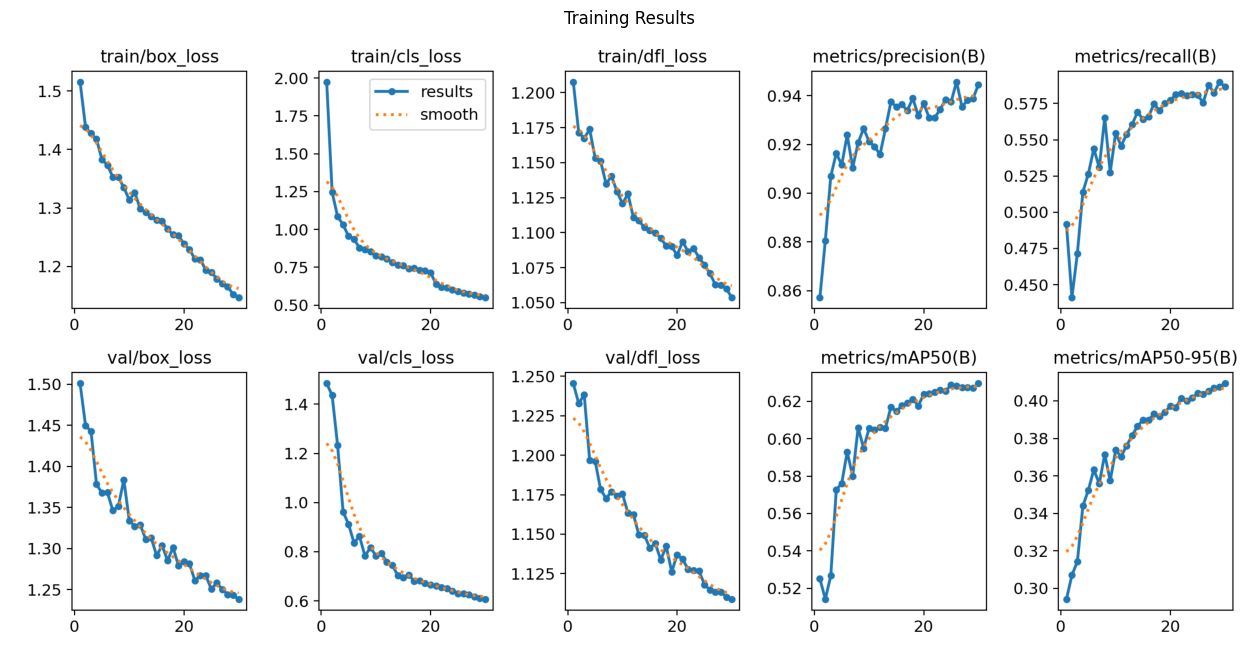

In [28]:
from PIL import Image
import matplotlib.pyplot as plt

results_path = "/kaggle/working/runs/detect/HardHat_Project/YOLOv8_Finetuning/results.png"

img = Image.open(results_path)

plt.figure(figsize=(16, 10))
plt.imshow(img)
plt.axis("off")
plt.title("Training Results")
plt.show()

* All training and validation losses (`box_loss`, `cls_loss`, `dfl_loss`) decreased steadily, indicating stable and effective learning.
* Precision, Recall, `mAP50`, and `mAP50-95` consistently improved throughout training, showing better detection performance over time.
* Both training and validation losses followed similar downward trends, suggesting **no significant overfitting**.
* The evaluation metrics began to plateau during the final epochs, indicating the model had **largely converged** and additional training would likely provide only marginal improvements.
* Overall, the model achieved stable convergence and is ready for detailed evaluation through confusion matrices and prediction analysis.


## 8.2 Analyze the Confusion Matrix

The confusion matrix helps identify which classes the model predicts correctly and where it makes mistakes.

Unlike overall metrics such as mAP or Precision, it provides class-by-class performance, making it easier to diagnose weak classes and common misclassifications.

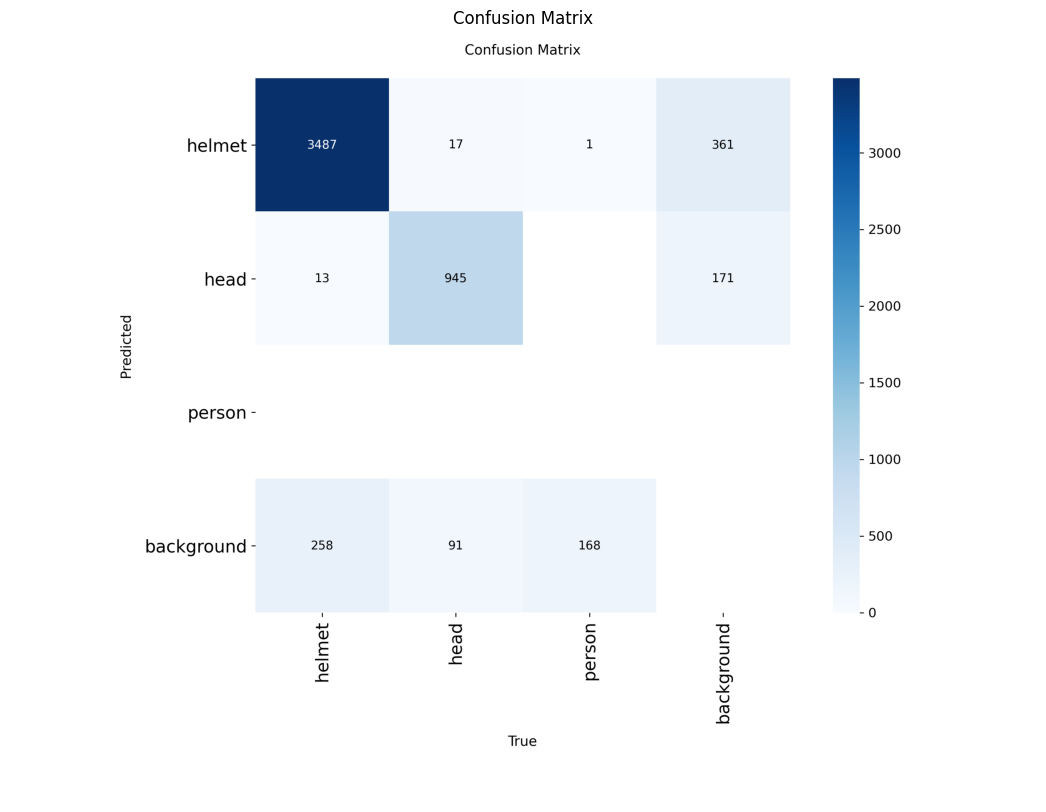

In [29]:
from PIL import Image
import matplotlib.pyplot as plt

cm_path = "/kaggle/working/runs/detect/HardHat_Project/YOLOv8_Finetuning/confusion_matrix.png"

img = Image.open(cm_path)

plt.figure(figsize=(16, 10))
plt.imshow(img)
plt.axis("off")
plt.title("Confusion Matrix")
plt.show()

- Helmet is the strongest class with high detection accuracy.
- Head is occasionally confused with helmet due to visual similarity.
- Person is the weakest class because of severe class imbalance and limited training examples.
- The confusion matrix confirms that the main bottleneck is dataset quality and class distribution, rather than unstable model training.

## 8.3 Analyze Dataset Distribution (`labels.jpg`)

`labels.jpg` is automatically generated by YOLO before training. It provides a summary of the dataset's annotation distribution.

It answers four important questions:

* Are the classes balanced?
* Where do objects usually appear in images?
* How large are the bounding boxes?
* Is there any obvious dataset bias?

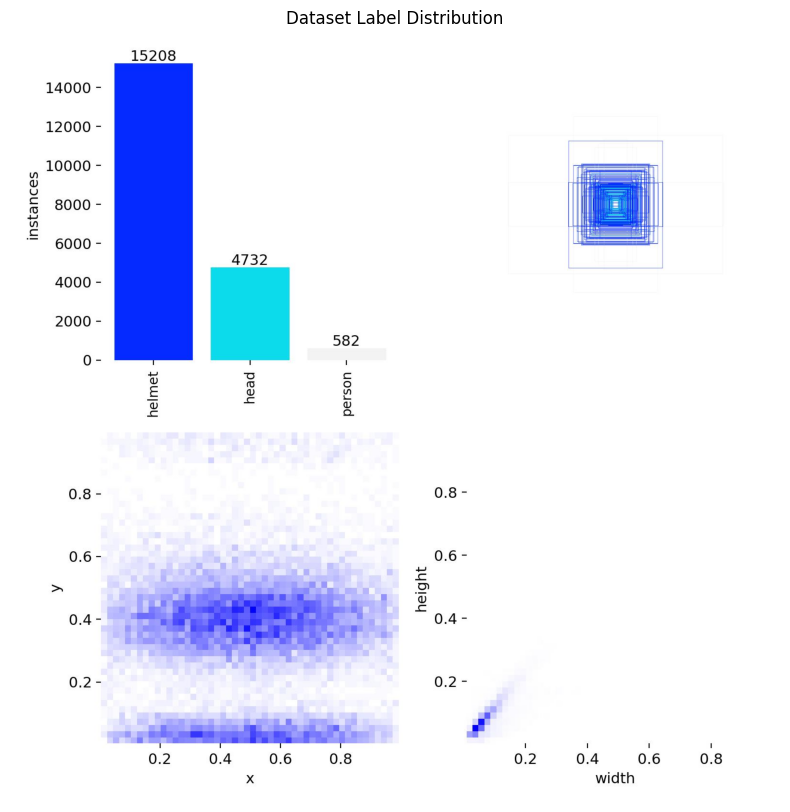

In [30]:
from PIL import Image
import matplotlib.pyplot as plt

labels_path = "/kaggle/working/runs/detect/HardHat_Project/YOLOv8_Finetuning/labels.jpg"

img = Image.open(labels_path)

plt.figure(figsize=(16, 10))
plt.imshow(img)
plt.axis("off")
plt.title("Dataset Label Distribution")
plt.show()

The dataset distribution shows that **helmet** is the dominant class (15,208 instances), followed by **head** (4,732), while **person** has only **582 instances**, indicating a strong class imbalance. Most objects are centered within the images and have consistent bounding box sizes, making localization easier for YOLO. However, the scarcity of person instances explains the model's comparatively poor performance on that class during evaluation.


## 8.4 Precision–Recall (PR) Curve Analysis

The Precision–Recall (PR) curve evaluates how well the detector balances **precision** (avoiding false positives) and **recall** (detecting as many true objects as possible).

Unlike overall accuracy, the PR curve is one of the most informative metrics for object detection because it evaluates model performance across different confidence thresholds.

A larger area under the PR curve indicates stronger detection performance.

### Why is this important?

- Shows how well the model balances precision and recall.
- Helps identify classes that are difficult to detect.
- The larger the area under the PR curve, the better the detector performs.
- A curve closer to the **top-right corner** indicates superior detection performance.




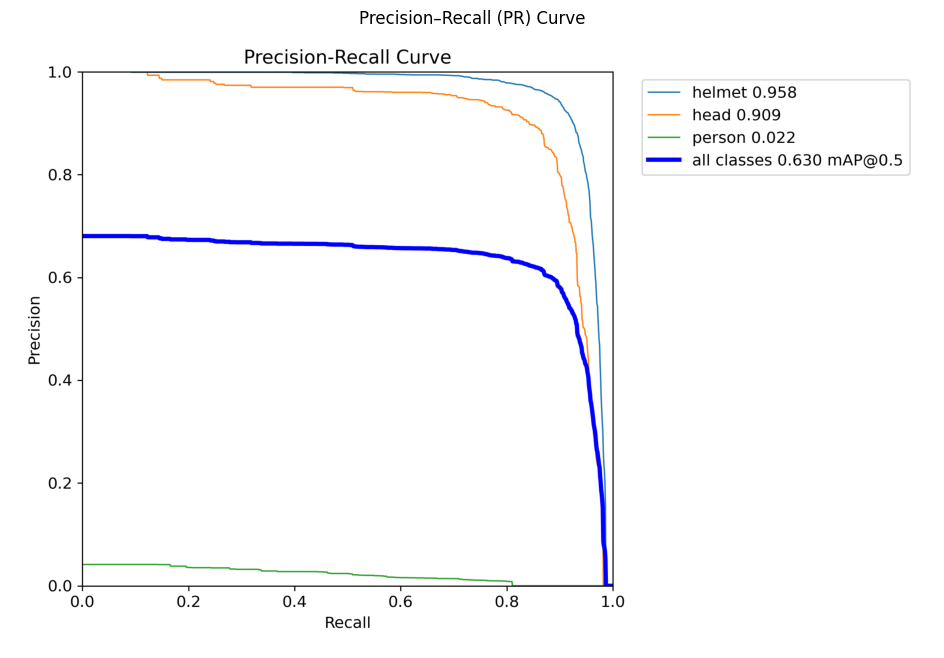

In [31]:
from PIL import Image
import matplotlib.pyplot as plt

pr_curve_path = "/kaggle/working/runs/detect/HardHat_Project/YOLOv8_Finetuning/BoxPR_curve.png"

img = Image.open(pr_curve_path)

plt.figure(figsize=(12, 8))
plt.imshow(img)
plt.axis("off")
plt.title("Precision–Recall (PR) Curve")
plt.show()

The Precision–Recall (PR) curve illustrates the trade-off between **Precision** and **Recall** for each object class at different confidence thresholds. A model with a larger area under the PR curve generally demonstrates stronger detection performance.

**Observations:**

- **Helmet** achieved the highest performance with an **Average Precision (AP) of 0.958**, indicating excellent detection accuracy across nearly all recall levels.
- **Head** also performed well with an **AP of 0.909**, although its precision declined more rapidly at very high recall values.
- **Person** achieved a very low **AP of 0.022**, showing that the model struggled to detect this class consistently.
- The overall model obtained an **mAP@0.5 of 0.630**, reflecting good performance on the dominant classes but being negatively affected by the poor detection of the minority class.

The weak performance on the **person** class is primarily due to the severe class imbalance observed in the dataset, where only **582 person instances** were available compared to over **15,000 helmet instances**.

## 8.5 F1 Score vs Confidence Threshold Analysis

The F1 Curve illustrates how the model's **F1 Score** changes as the **confidence threshold** varies.

The **F1 Score** is the harmonic mean of **Precision** and **Recall**, balancing the trade-off between detecting as many objects as possible while minimizing false detections.

This curve is particularly useful for selecting the optimal confidence threshold for deployment, where both precision and recall should be balanced.

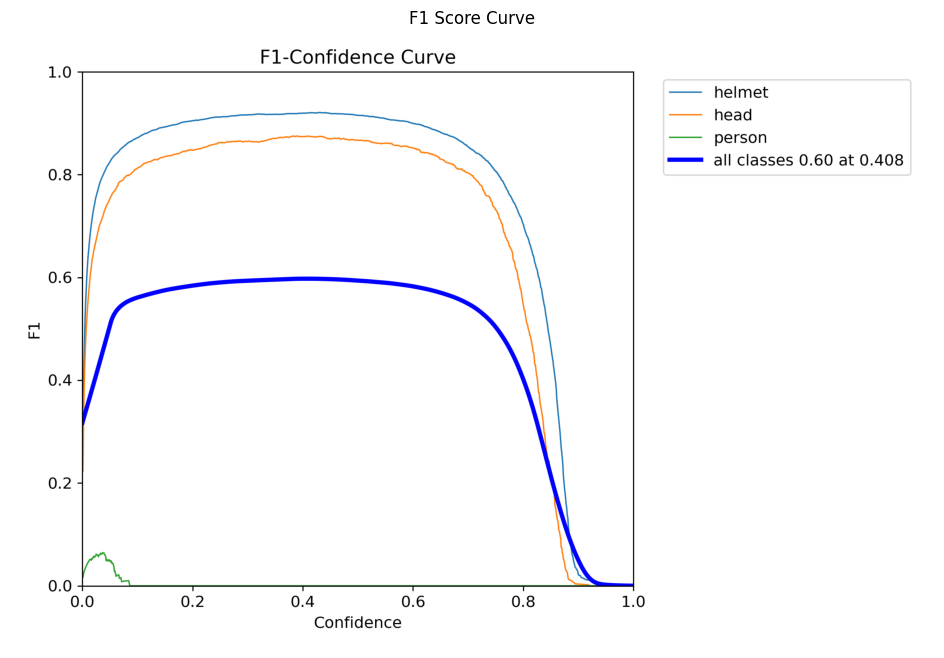

In [32]:
from PIL import Image
import matplotlib.pyplot as plt

f1_curve_path = "/kaggle/working/runs/detect/HardHat_Project/YOLOv8_Finetuning/BoxF1_curve.png"

img = Image.open(f1_curve_path)

plt.figure(figsize=(12, 8))
plt.imshow(img)
plt.axis("off")
plt.title("F1 Score Curve")
plt.show()

The F1 Score Curve illustrates how the model's **F1 Score** changes as the prediction confidence threshold increases.

The **F1 Score** combines **Precision** and **Recall** into a single metric, making it particularly useful when both false positives and false negatives are important.

**Observations:**

- The **helmet** class achieved the highest F1 score, remaining above **0.90** across a wide range of confidence thresholds.
- The **head** class also demonstrated strong and stable performance with an F1 score close to **0.88**.
- The **person** class maintained a very low F1 score throughout the evaluation, indicating poor detection performance due to the limited number of training examples.
- The overall model reached its **maximum F1 score of 0.60 at a confidence threshold of approximately 0.408**, which represents the optimal operating point where Precision and Recall are best balanced.

## 8.6 Precision & Recall vs Confidence Analysis

The Precision and Recall curves illustrate how the model's prediction quality changes as the confidence threshold increases.

These curves help determine the trade-off between detecting more objects (Recall) and reducing false detections (Precision), making them valuable for selecting an appropriate confidence threshold during deployment.

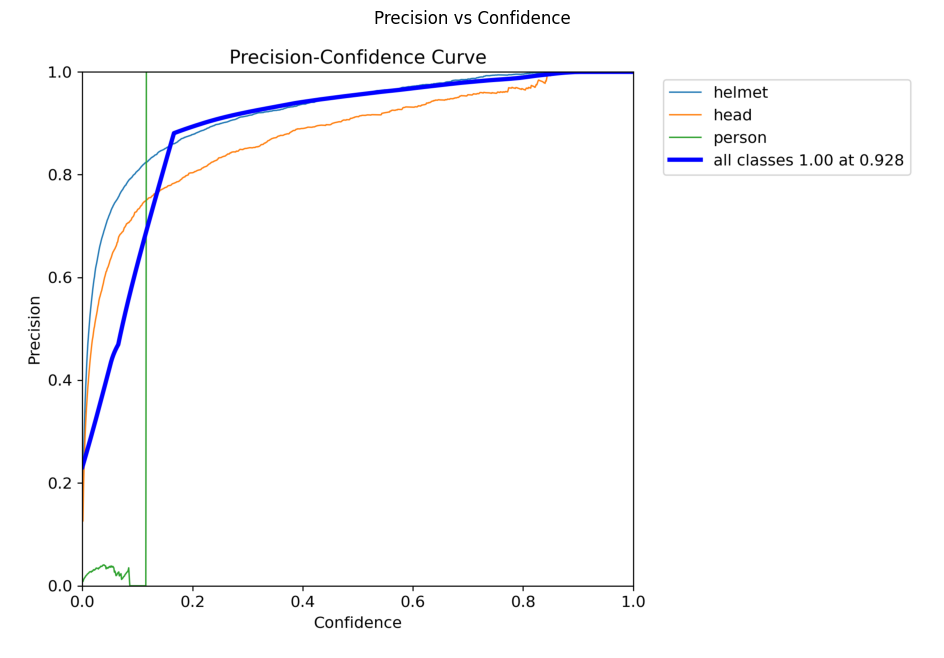

In [33]:
from PIL import Image
import matplotlib.pyplot as plt

precision_curve_path = "/kaggle/working/runs/detect/HardHat_Project/YOLOv8_Finetuning/BoxP_curve.png"

img = Image.open(precision_curve_path)

plt.figure(figsize=(12, 8))
plt.imshow(img)
plt.axis("off")
plt.title("Precision vs Confidence")
plt.show()

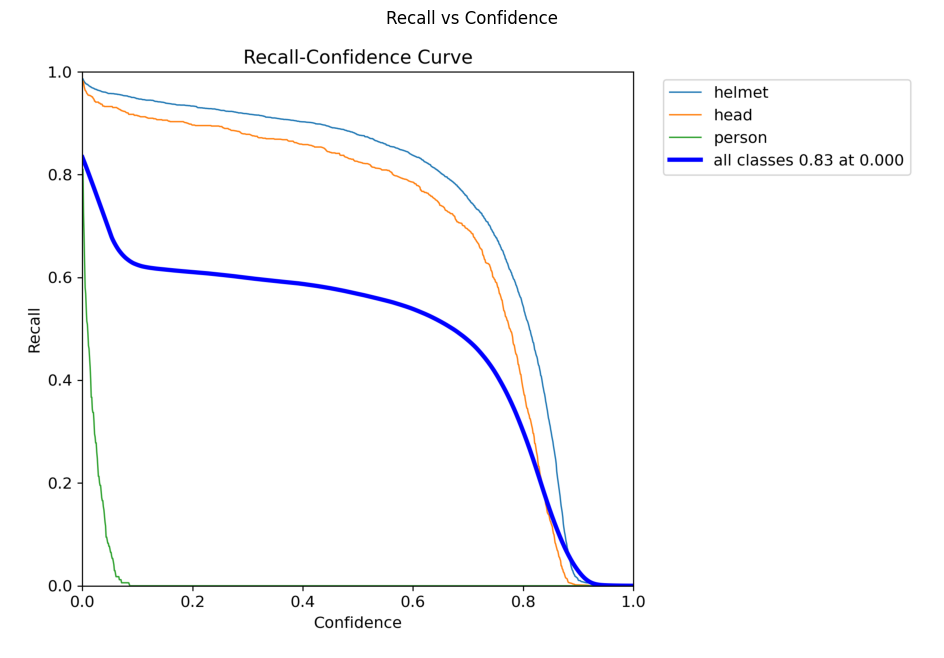

In [34]:
from PIL import Image
import matplotlib.pyplot as plt

recall_curve_path = "/kaggle/working/runs/detect/HardHat_Project/YOLOv8_Finetuning/BoxR_curve.png"

img = Image.open(recall_curve_path)

plt.figure(figsize=(12, 8))
plt.imshow(img)
plt.axis("off")
plt.title("Recall vs Confidence")
plt.show()


- Increasing the confidence threshold increases precision because the model becomes more selective about its predictions.
- Increasing the confidence threshold decreases recall because more valid detections are rejected.
- The Precision–Confidence curve shows that overall precision reaches approximately 1.00 at a high confidence threshold (~0.928).
- The Recall–Confidence curve shows that recall is highest at very low confidence and progressively decreases as the threshold increases.
- Therefore, confidence threshold selection is a trade-off between precision and recall and should depend on the application's priority.
- For this model, the curves also reinforce the earlier finding that the `person` class is performing poorly compared with `helmet` and `head`.

## 8.7 Qualitative Prediction Analysis

We’ve already analyzed the training behavior and metric curves. Now we need to answer a different question:

> **“What does the model actually detect correctly and incorrectly on real validation images?”**

This is important because metrics like mAP tell us **how well**, but prediction images show us **where and why it succeeds or fails**.

From our available files, the most useful ones now are:

* `val_batch0_labels.jpg` → ground truth
* `val_batch0_pred.jpg` → model predictions
* `val_batch1_labels.jpg` → ground truth
* `val_batch1_pred.jpg` → model predictions

We don't need to display all six batches. **Batch 0 is enough for the first analysis.**


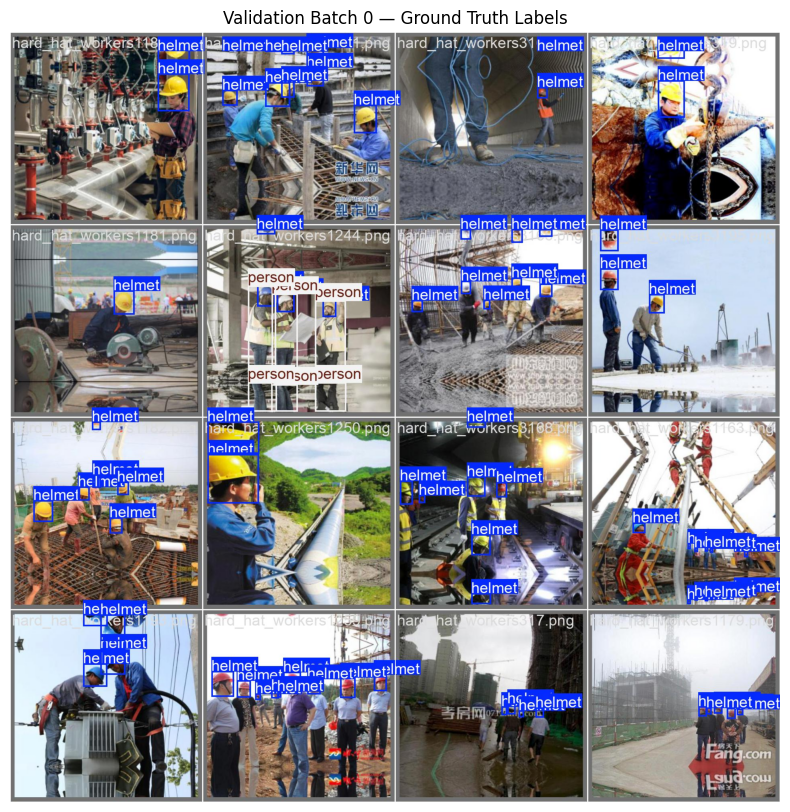

In [35]:
from PIL import Image
import matplotlib.pyplot as plt

# Path to the ground-truth validation image
val_labels_path = (
    "/kaggle/working/runs/detect/HardHat_Project/"
    "YOLOv8_Finetuning/val_batch0_labels.jpg"
)

# Load the image
img = Image.open(val_labels_path)

# Display the ground-truth annotations
plt.figure(figsize=(16, 10))
plt.imshow(img)
plt.axis("off")
plt.title("Validation Batch 0 — Ground Truth Labels")
plt.show()

The validation batch contains varied and challenging scenes, with helmet annotations dominating and person annotations appearing much less frequently. The ground-truth labels appear generally well positioned, but the class imbalance and presence of small, overlapping, and distant objects make detection challenging.

## 8.8 Prediction Analysis

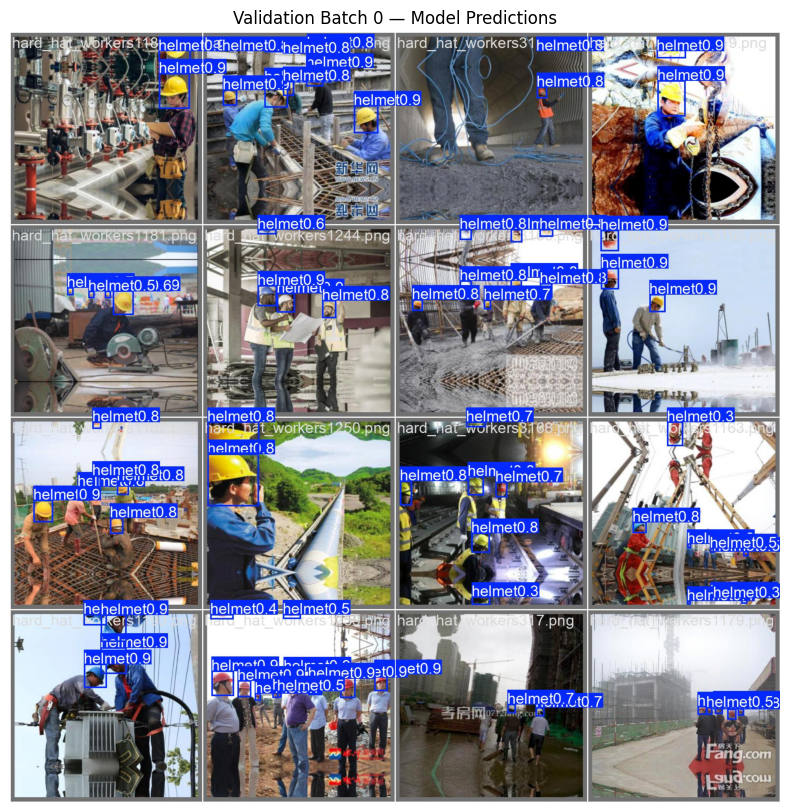

In [36]:
from PIL import Image
import matplotlib.pyplot as plt

# Path to the model's predictions on validation batch 0
val_pred_path = (
    "/kaggle/working/runs/detect/HardHat_Project/"
    "YOLOv8_Finetuning/val_batch0_pred.jpg"
)

# Load the prediction visualization
img = Image.open(val_pred_path)

# Display model predictions
plt.figure(figsize=(16, 10))
plt.imshow(img)
plt.axis("off")
plt.title("Validation Batch 0 — Model Predictions")
plt.show()

* **Helmet detection is generally strong.** The model detects helmets across different environments: construction sites, industrial areas, pipelines, scaffolding, and outdoor scenes.
* **Confidence is mostly high**, commonly around **0.7–0.9+**, indicating reasonably confident helmet predictions.
* **Small/distant helmets are still detected**, which is important for real-world safety monitoring.
* Some predictions have **lower confidence (~0.3–0.5)**, particularly where helmets are small, partially occluded, or visually difficult.
* Several images contain **multiple workers**, and the model can identify multiple helmets in the same scene.
* The predictions appear focused primarily on the **helmet class**, which aligns with the actual project objective.

## 8.9 Prediction vs Ground Truth

Now we compare what actually exists in the annotations against what YOLO predicted.

For this project, the key question is:

> **Did the model detect the helmets that are actually present, and did it avoid detecting helmets where there aren't any?**

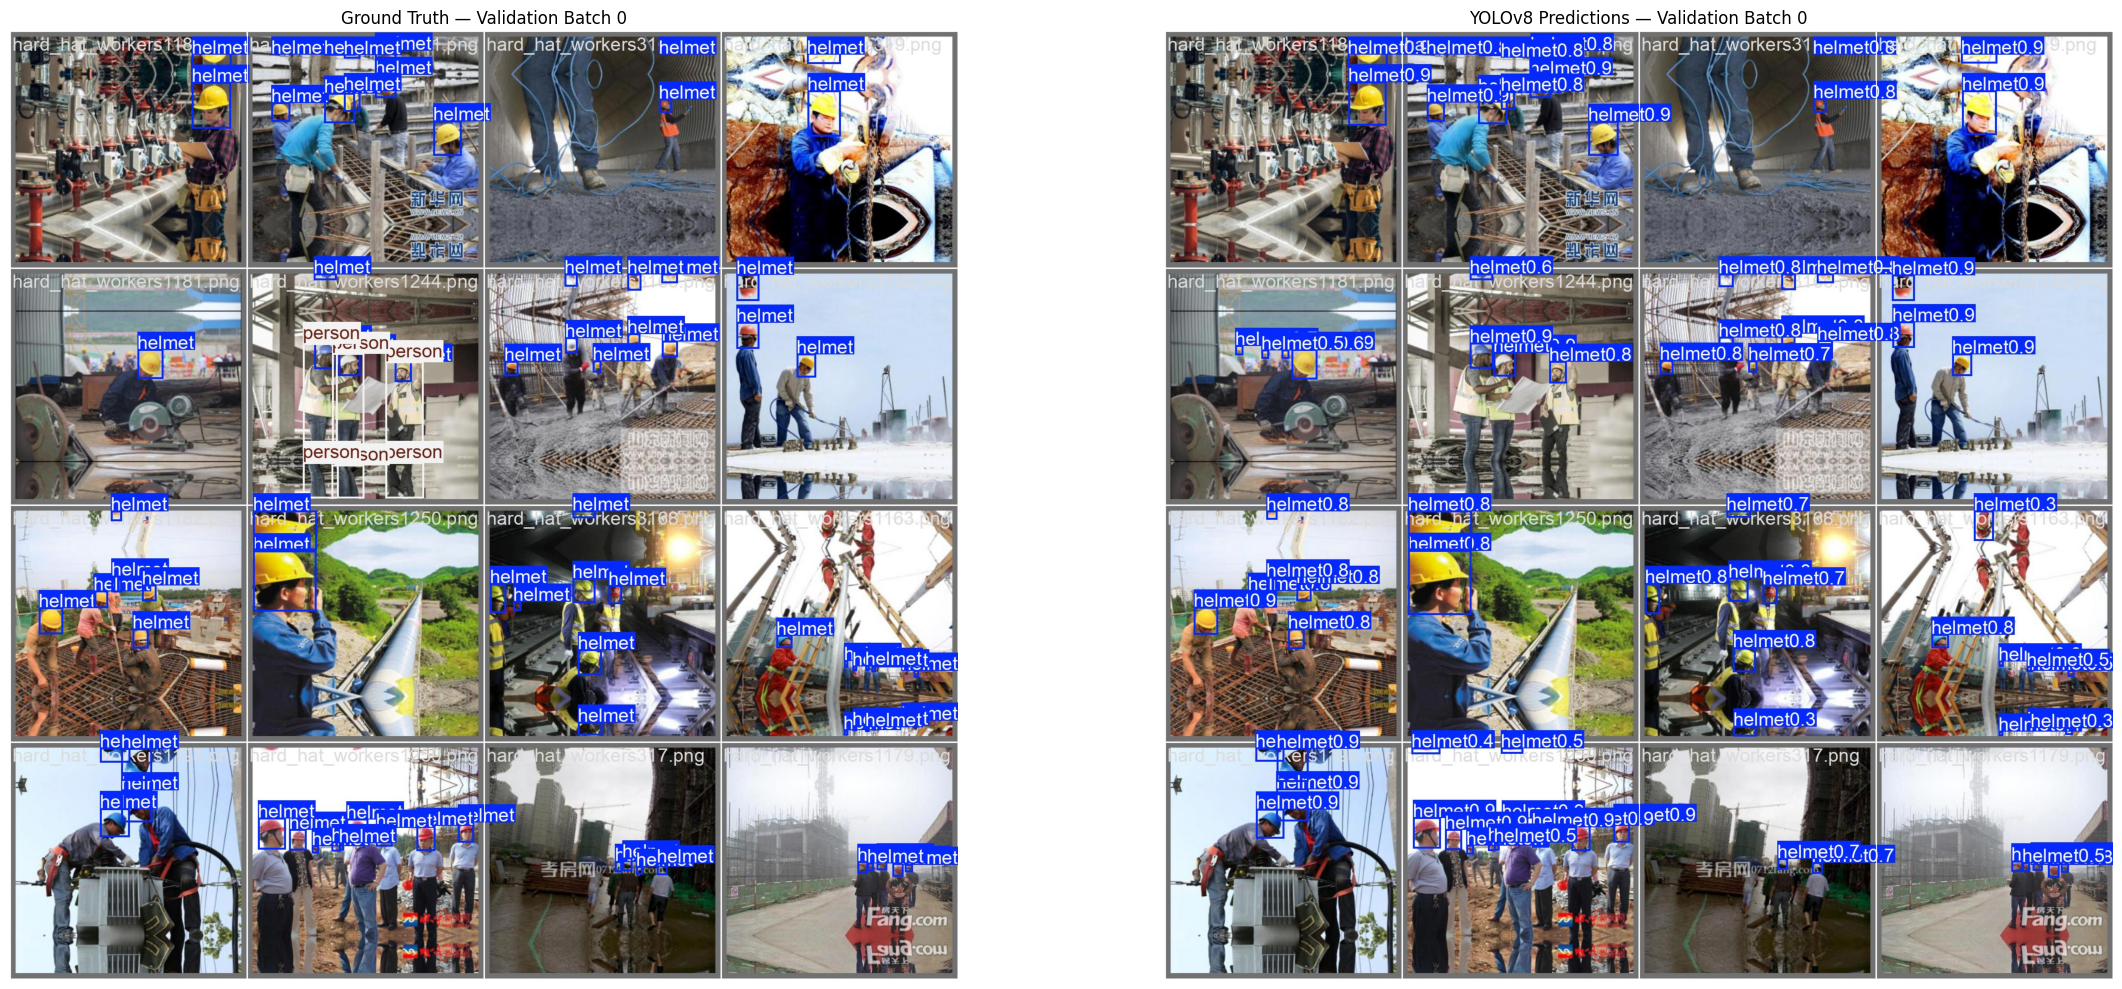

In [37]:
from PIL import Image
import matplotlib.pyplot as plt

# Ground Truth
labels_path = (
    "/kaggle/working/runs/detect/HardHat_Project/"
    "YOLOv8_Finetuning/val_batch0_labels.jpg"
)

# Model Predictions
pred_path = (
    "/kaggle/working/runs/detect/HardHat_Project/"
    "YOLOv8_Finetuning/val_batch0_pred.jpg"
)

# Load images
labels_img = Image.open(labels_path)
pred_img = Image.open(pred_path)

# Display side-by-side
fig, axes = plt.subplots(1, 2, figsize=(24, 10))

axes[0].imshow(labels_img)
axes[0].axis("off")
axes[0].set_title("Ground Truth — Validation Batch 0")

axes[1].imshow(pred_img)
axes[1].axis("off")
axes[1].set_title("YOLOv8 Predictions — Validation Batch 0")

plt.tight_layout()
plt.show()

* ✅ Most visible helmets in the ground truth also appear in the predictions.
* ✅ The predicted boxes are generally positioned around the correct helmet locations.
* ✅ The model handles multiple helmets in crowded scenes, which is important for construction-site monitoring.
* ✅ Confidence is generally high for clear helmets (`0.7–0.9+`).
* ⚠️ Some small or difficult helmets receive **lower confidence** (`~0.3–0.6`).
* ⚠️ In crowded images, prediction labels can overlap, making the output visually cluttered.
* ⚠️ Some ground-truth `person` annotations are not predicted as `person`, which is consistent with the very poor `person` recall (**0.000**). However, **person detection is not the primary objective of this hard-hat project**.

<p style="text-align:center; color:red; font-size:18px;"> To be continue...</p>

---

<p style="text-align:center; color:skyblue; font-size:18px;">
© 2026 Mostafizur Rahman
</p>
